In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

In [2]:
RAW = Path("../data/raw") 
orders = pd.read_csv(RAW / "olist_orders_dataset.csv") 
customers = pd.read_csv(RAW / "olist_customers_dataset.csv") 
items = pd.read_csv(RAW / "olist_order_items_dataset.csv") 
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv") 
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv") 
products = pd.read_csv(RAW / "olist_products_dataset.csv") 
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv") 
geo = pd.read_csv(RAW / "olist_geolocation_dataset.csv") 
cat_trans = pd.read_csv(RAW / "product_category_name_translation.csv") 
dfs = {"orders":orders, "customers":customers, "items":items, "payments":payments, "reviews":reviews, "products":products, "sellers":sellers, "geo":geo, "cat_trans":cat_trans}

## Handle duplicates — average lat/lng per zip prefix

In [3]:
# geo has multiple lat/lng per zip — deduplicate by averaging
geo_clean = geo.groupby("geolocation_zip_code_prefix").agg( lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean"), state=("geolocation_state", "first") ).reset_index() 
print(f"Unique zip prefixes: {len(geo_clean)}")

Unique zip prefixes: 19015


## Customer density by state

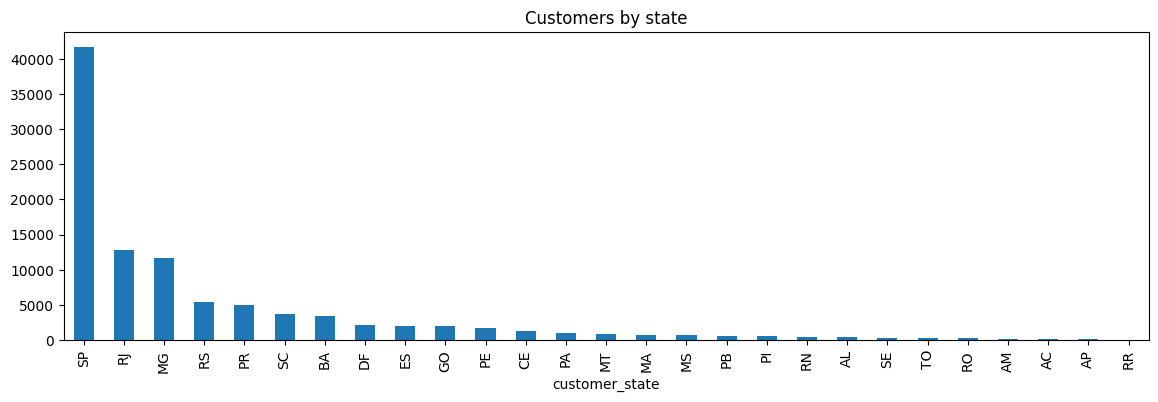

In [4]:
cust_state = customers["customer_state"].value_counts() 
cust_state.plot(kind="bar", title="Customers by state", figsize=(14,4)) 
plt.savefig("../reports/figures/1.4-customers-by-state.png", dpi=150) # Expect: SP dominant, then RJ, MG

## Scatter plot — customer locations across Brazil

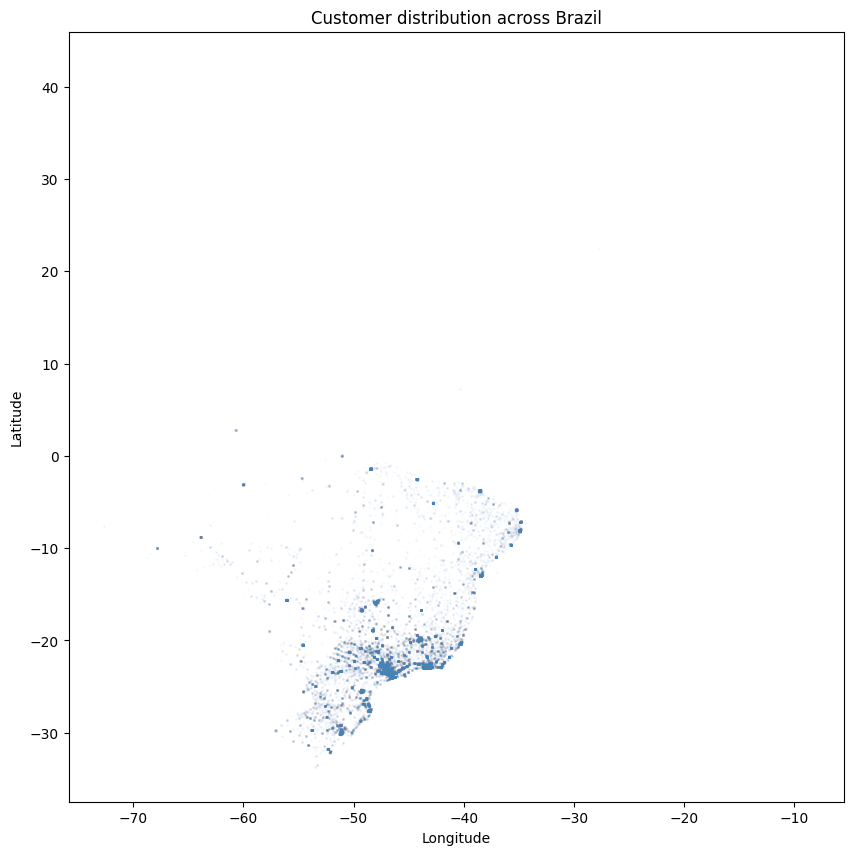

In [5]:
# Quick geographic scatter — no external map needed 
cust_geo = customers.merge( geo_clean, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
fig, ax = plt.subplots(figsize=(10,10)) 
ax.scatter(cust_geo["lng"], cust_geo["lat"], alpha=0.01, s=1, color="steelblue") 
ax.set_title("Customer distribution across Brazil") 
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude") 
plt.savefig("../reports/figures/1.4-customer-geo-scatter.png", dpi=150)